In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from sklearn import metrics
from keras import optimizers

In [16]:
red = pd.read_csv("redwinequality.csv", sep=";")
white = pd.read_csv("whitewinequality.csv", sep=";")

In [17]:
red['type'] = 1
white['type'] = 0

wines = pd.concat([red, white], ignore_index=True)
wines.dropna(inplace=True)

In [18]:
X = wines.drop('type', axis=1)
Y = wines.loc[:, ['type']]

In [19]:
X_train, X_test, Y_train,  Y_test = train_test_split(
    X,
    Y,
    test_size=0.15,
    random_state=42

)

In [ ]:
model = Sequential()
model.add(Dense(12, activation='relu', input_dim=12))
model.add(Dense(15, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
opt = optimizers.Adam(learning_rate=0.00003)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy', 'recall'], validation_data=(X_test, Y_test)) 

In [ ]:
model.fit(X_train, Y_train, epochs=10000, batch_size=20, verbose=1)

Epoch 1/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 5s 836us/step - accuracy: 0.9277 - loss: 0.2242 - recall: 0.7864
Epoch 2/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 5s 857us/step - accuracy: 0.9457 - loss: 0.1523 - recall: 0.8237
Epoch 3/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 5s 832us/step - accuracy: 0.9524 - loss: 0.1297 - recall: 0.8566
Epoch 4/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 5s 826us/step - accuracy: 0.9658 - loss: 0.1034 - recall: 0.9022
Epoch 5/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 4s 809us/step - accuracy: 0.9679 - loss: 0.0999 - recall: 0.9119
Epoch 6/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 4s 811us/step - accuracy: 0.9699 - loss: 0.0941 - recall: 0.9208
Epoch 7/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 5s 936us/step - accuracy: 0.9732 - loss: 0.0875 - recall: 0.9276
Epoch 8/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 5s 910us/step - accuracy: 0.9725 - loss: 0.0883 - recall: 0.9238
Epoch 9/100
5522/5522 ━━━━━━━━━━━━━━━━━━━━ 5s 866us/step - accuracy: 0.9743 - loss: 0.0861 - recall: 0.9291
Epoch 10/100
5522/5522 ━━━━━

In [110]:
y_pred = model.predict(X_test)
y_pred_labels = pd.DataFrame((y_pred >= 0.5).astype(int)).rename(columns={0: 'predicted_type'})

tester = pd.concat([y_pred_labels, Y_test.reset_index()], axis=1).drop('index', axis=1)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


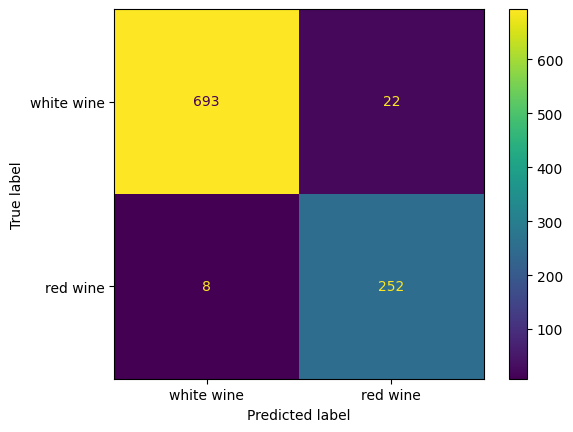

In [111]:
matrix = metrics.confusion_matrix(tester['type'], tester['predicted_type'])
display = metrics.ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=('white wine', 'red wine'))
display.plot()
plt.show()

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

In [2]:
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Text(0.5, 1.0, 'Shirt')

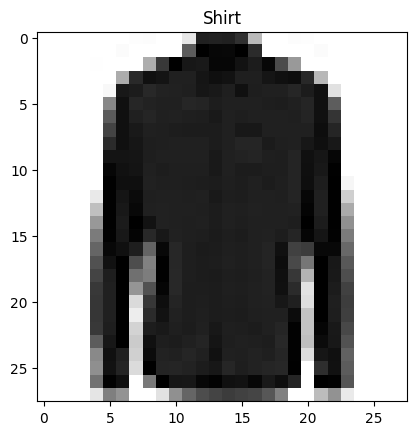

In [11]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

f = 39
plt.imshow(train_data[f],cmap=plt.cm.binary)
plt.title(class_names[train_labels[f]])

In [27]:
train_data_norm = train_data / train_data.max()
test_data_norm = test_data / test_data.max()

In [34]:
model2 = Sequential()
model2.add(Flatten(input_shape= train_data[0].shape))
model2.add(Dense(9, activation='relu'))
model2.add(Dense(8, activation='relu'))
model2.add(Dense(10, activation='softmax'))

model2.compile(loss='Crossentropy', optimizer='Adam', metrics=['Accuracy'])

norm_history = model2.fit(
    train_data_norm,
    train_labels,
    epochs=5,
    batch_size=20,
    validation_data=(test_data_norm, test_labels),
    verbose = 1
 )

Epoch 1/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - Accuracy: 0.7517 - loss: 0.7014 - val_Accuracy: 0.8127 - val_loss: 0.5444
Epoch 2/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - Accuracy: 0.8233 - loss: 0.5007 - val_Accuracy: 0.8179 - val_loss: 0.5170
Epoch 3/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - Accuracy: 0.8343 - loss: 0.4652 - val_Accuracy: 0.8326 - val_loss: 0.4727
Epoch 4/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - Accuracy: 0.8417 - loss: 0.4441 - val_Accuracy: 0.8331 - val_loss: 0.4673
Epoch 5/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - Accuracy: 0.8474 - loss: 0.4280 - val_Accuracy: 0.8405 - val_loss: 0.4529


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


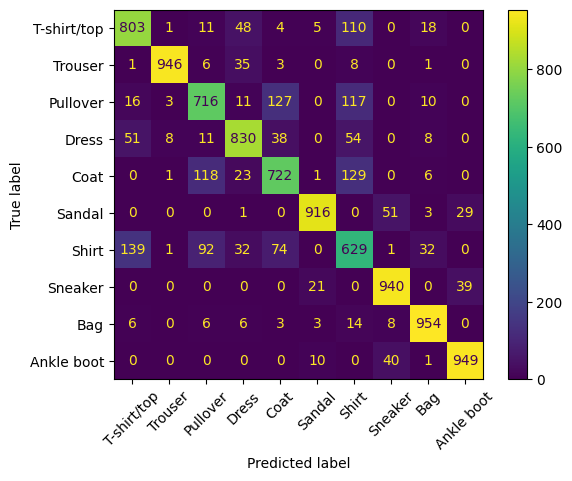

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model2.predict(test_data_norm).argmax(axis=1)
y_true = test_labels
matrix2 = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(matrix2, display_labels=class_names).plot(xticks_rotation=45)

plt.show()